In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
ratings=pd.read_csv("/Users/harshverma/Downloads/machine learning /movie recommendation system/ml-latest-small/ratings.csv")
movies =pd.read_csv("/Users/harshverma/Downloads/machine learning /movie recommendation system/ml-latest-small/movies.csv")
links  =pd.read_csv("/Users/harshverma/Downloads/machine learning /movie recommendation system/ml-latest-small/links.csv")
tags   =pd.read_csv("/Users/harshverma/Downloads/machine learning /movie recommendation system/ml-latest-small/tags.csv")
print(ratings.shape)
print(movies.shape)
print(tags.shape)
print(links.shape)

(100836, 4)
(9742, 3)
(3683, 4)
(9742, 3)


In [30]:
# check for any null values ,,understand the data 
print(ratings.info())
print(movies.info())
print(movies.duplicated().sum())
print(ratings.duplicated().sum())
#no null values and no duplicates 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None
0
0


ratingsscale, minimum= 0.5 maximum= 5.0 unique values
unique ratings [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


<Axes: title={'center': 'Rating Distribution'}, xlabel='rating'>

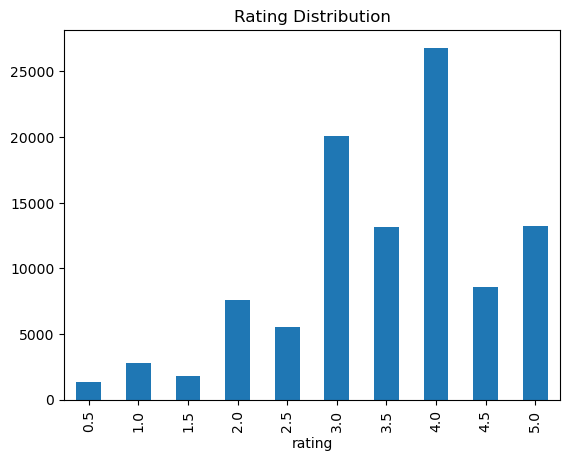

In [ ]:
print("ratingsscale, minimum=",ratings['rating'].min(),"maximum=",ratings['rating'].max(),"unique values")
print("unique ratings",sorted(ratings['rating'].unique()))
ratings['rating'].value_counts().sort_index().plot(
    kind='bar',
    title='Rating Distribution'
)
# how many times this rating is recieved 

In [20]:
#ratings per user 
ratings_per_user=ratings.groupby('userId').size()
print("min_rating",ratings_per_user.min(),
      "max_rating",ratings_per_user.max(),
      "rating_per_",ratings_per_user.mean())

min_rating 20 max_rating 2698 rating_per_ 165.30491803278687


In [23]:
#ratings per movie how many times a movies is rated maximum or minimum
ratings_per_movie=ratings.groupby('movieId').size()
print("min_rating",ratings_per_movie.min(),
      "max_rating",ratings_per_movie.max(),
      "rating_per_",ratings_per_movie.mean())
# print(ratings_per_movie)

min_rating 1 max_rating 329 rating_per_ 10.369806663924312


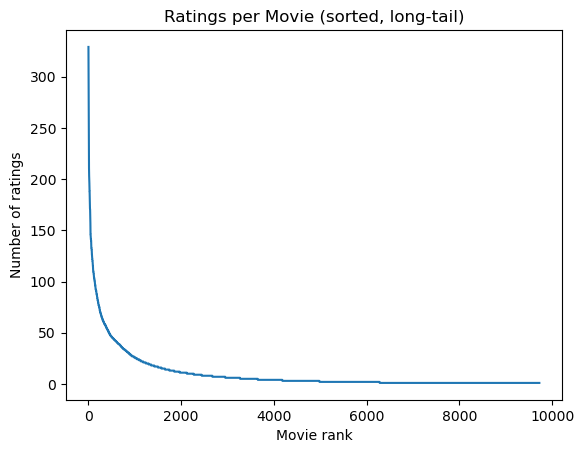

In [29]:
ratings_per_movie.sort_values(ascending=False).reset_index(drop=True).plot(
    title='Ratings per Movie (sorted, long-tail)'
)
plt.xlabel('Movie rank')
plt.ylabel('Number of ratings')
plt.show()

In [41]:
#sparsity check means (no of enteries/total no of possible enteries) 
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)
print("users",num_users,"movies",num_movies,"ratings",num_ratings)
print(f"sparsity: {1 - (num_ratings / (num_users * num_movies)):.4%}")

users 610 movies 9724 ratings 100836
sparsity: 98.3000%


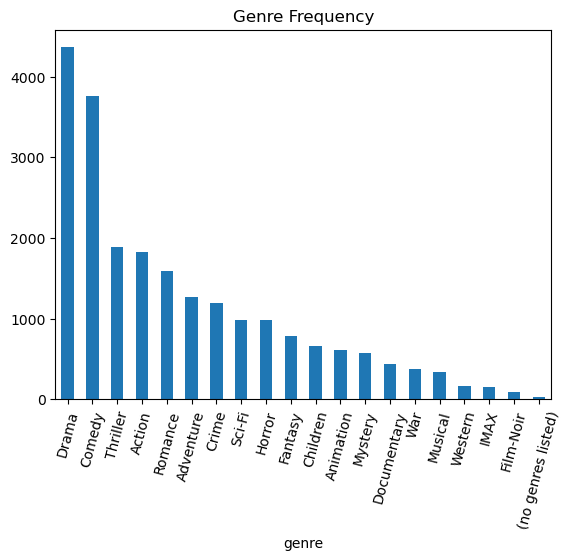

single genre 2851
multiple genre 6891


In [ ]:
# genre exploration
movies['genre_list'] = movies['genres'].str.split('|')
all_genres = [g for genre_list in movies['genre_list'] for g in genre_list]
genre_counts = Counter(all_genres)
#creting a new dataset to see the freq of generes
#items make pairs 
genre_df = pd.DataFrame(
    genre_counts.items(),
    columns=['genre', 'count']
).sort_values('count', ascending=False)
# ploting 
genre_df.plot(kind='bar', x='genre', y='count', title='Genre Frequency', legend=False)
plt.xticks(rotation=75)
plt.show()
movies['num_genres'] = movies['genre_list'].apply(len)
print("single genre",(movies['num_genres'] == 1).sum())
print("multiple genre",(movies['num_genres'] > 1).sum())

In [56]:
#timestamp conversion
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
print("Date range:", ratings['datetime'].min(), "to", ratings['datetime'].max())

Date range: 1996-03-29 18:36:55 to 2018-09-24 14:27:30


In [62]:
#merging the ratings and movies 
merged = ratings.merge(movies, on='movieId', how='left')
print("Ratings rows:", len(ratings))
print("Merged rows:", len(merged))
print("Unmatched:", merged['title'].isnull().sum())

Ratings rows: 100836
Merged rows: 100836
Unmatched: 0
